# 배송 지연 × 고객 평점 EDA

**데이터**: `data/processed/olist_order_item_level.csv`  
**분석 목적**: 배송 지연이 고객 만족도(review_score)에 미치는 영향을 정량화하고,  
고객이 인내할 수 있는 배송 지연 임계일(골든타임)을 도출한다.

| # | 분석 | 핵심 질문 |
|---|------|----------|
| 1 | 지연일별 평균 평점 추이 | 평점이 급락하는 지점은 언제인가? |
| 2 | 지연/비지연별 평점 분포 | 지연 여부에 따라 1~5점 구성이 어떻게 달라지는가? |
| 3 | 판매자 귀책 지연 × 평점 | 물류사 인도 병목 구간에서 평점이 어떻게 변화하는가? |
| 4 | 고객 인내 임계일 시각화 | 사전 개입이 필요한 지점을 어떻게 정의할 것인가? |

In [60]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 120

ROOT = Path('../../').resolve()
df_raw = pd.read_csv(ROOT / 'data/processed/olist_order_item_level.csv')

for c in ['order_delivered_customer_date', 'order_estimated_delivery_date',
          'order_delivered_carrier_date', 'shipping_limit_date', 'order_approved_at']:
    df_raw[c] = pd.to_datetime(df_raw[c], errors='coerce')

# 배송 완료 + 이상치 제거
df = df_raw[(df_raw['is_delivered'] == True) & (df_raw['anomaly_flag'] == 0)].copy()

df['delay_days']        = (df['order_delivered_customer_date'] - df['order_estimated_delivery_date']).dt.days
df['is_late']           = df['delay_days'] > 0
df['seller_delay_days'] = (df['order_delivered_carrier_date'] - df['shipping_limit_date']).dt.days
df['is_seller_late']    = df['seller_delay_days'] > 0
df['score_int']         = df['review_score_mean'].round().astype('Int64')

bins   = [-999, -1, 0, 3, 7, 14, 30, 999]
labels = ['조기배송', '정시(0일)', '1~3일', '4~7일', '8~14일', '15~30일', '30일 초과']
df['delay_bucket'] = pd.cut(df['delay_days'], bins=bins, labels=labels)

print(f'분석 대상: {len(df):,}건 (배송완료 + 이상치 제거)')
print(f'지연 주문: {df["is_late"].sum():,}건 ({df["is_late"].mean()*100:.1f}%)')
print(f'판매자 귀책 지연: {df["is_seller_late"].sum():,}건 ({df["is_seller_late"].mean()*100:.1f}%)')

분석 대상: 108,605건 (배송완료 + 이상치 제거)
지연 주문: 7,238건 (6.7%)
판매자 귀책 지연: 5,123건 (4.7%)


---
## 1. 배송 지연일 기준 평균 평점 추이 — 급락 지점 탐색

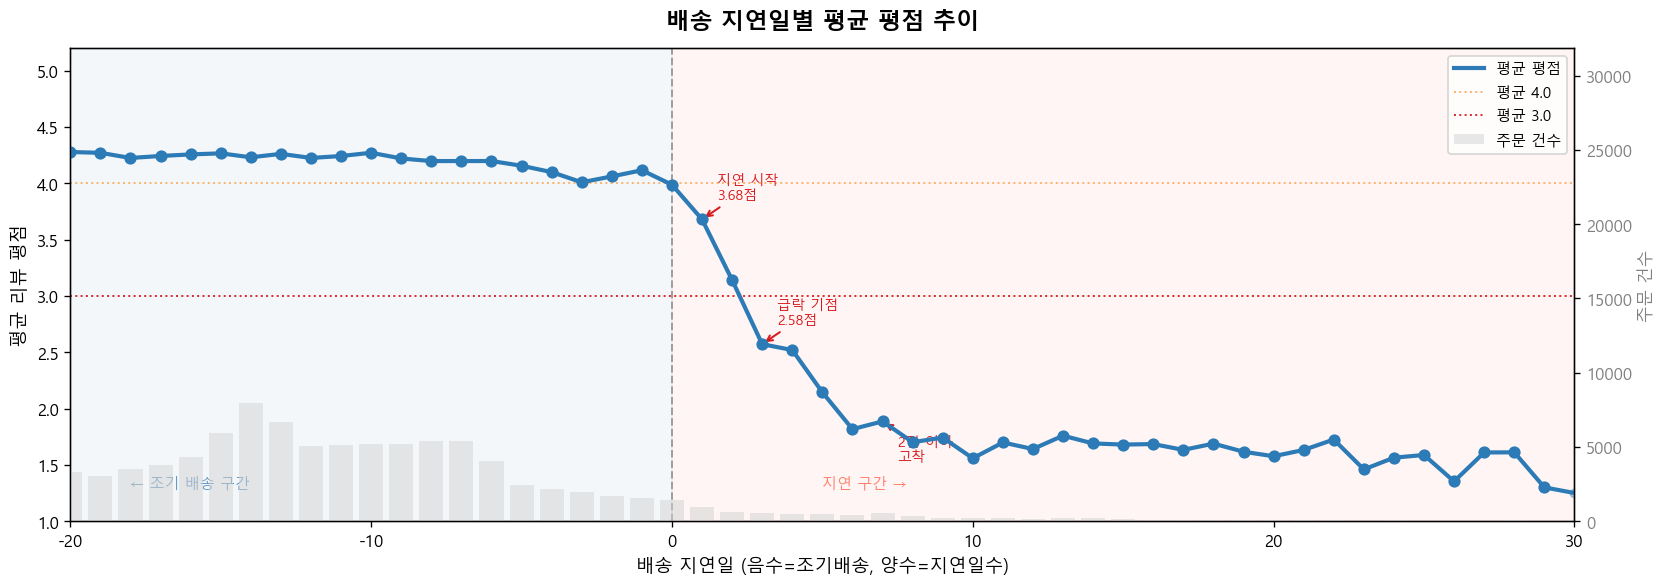


▶ 지연일 -2 ~ +10일 평균 평점
 delay_days  mean_score  order_cnt
       -2.0    4.060070       1723
       -1.0    4.114899       1584
        0.0    3.986335       1427
        1.0    3.678879        928
        2.0    3.140411        584
        3.0    2.570922        564
        4.0    2.518908        476
        5.0    2.143878        490
        6.0    1.816934        437
        7.0    1.885553        533
        8.0    1.701087        368
        9.0    1.741667        240
       10.0    1.558296        223


In [61]:
score_by_delay = (
    df.groupby('delay_days')['review_score_mean']
    .agg(mean_score='mean', order_cnt='count')
    .loc[-20:30]
    .reset_index()
)
sparse = score_by_delay['order_cnt'] < 30

fig, ax1 = plt.subplots(figsize=(14, 5))
ax2 = ax1.twinx()

ax1.axvspan(-20, 0, alpha=0.06, color='steelblue')
ax1.axvspan(0,  30, alpha=0.06, color='tomato')
ax1.axvline(x=0, color='gray', lw=1.2, ls='--', alpha=0.7)

ax2.bar(score_by_delay['delay_days'], score_by_delay['order_cnt'],
        color='lightgray', alpha=0.5, width=0.8, label='주문 건수')
ax2.set_ylabel('주문 건수', color='gray', fontsize=10)
ax2.tick_params(axis='y', labelcolor='gray')
ax2.set_ylim(0, score_by_delay['order_cnt'].max() * 4)

ax1.plot(score_by_delay['delay_days'], score_by_delay['mean_score'],
         color='#2c7bb6', lw=2.5, zorder=5, label='평균 평점')
ax1.scatter(score_by_delay.loc[sparse, 'delay_days'],
            score_by_delay.loc[sparse, 'mean_score'],
            color='#2c7bb6', s=25, alpha=0.35, zorder=6)
ax1.scatter(score_by_delay.loc[~sparse, 'delay_days'],
            score_by_delay.loc[~sparse, 'mean_score'],
            color='#2c7bb6', s=40, zorder=7)

for xval, label_txt, yoff in [(1, '지연 시작\n3.68점', 0.18),
                               (3, '급락 기점\n2.58점', 0.18),
                               (7, '2점 이하\n고착',    -0.35)]:
    row = score_by_delay[score_by_delay['delay_days'] == xval]
    if not row.empty:
        yval = row['mean_score'].values[0]
        ax1.annotate(label_txt, xy=(xval, yval), xytext=(xval + 0.5, yval + yoff),
                     fontsize=8.5, color='#d7191c',
                     arrowprops=dict(arrowstyle='->', color='#d7191c', lw=1.2))

for y, col, lbl in [(4.0, '#fdae61', '평균 4.0'), (3.0, '#d7191c', '평균 3.0')]:
    ax1.axhline(y=y, color=col, lw=1.2, ls=':', alpha=0.9, label=lbl)

ax1.set_xlabel('배송 지연일 (음수=조기배송, 양수=지연일수)', fontsize=11)
ax1.set_ylabel('평균 리뷰 평점', fontsize=11)
ax1.set_ylim(1, 5.2)
ax1.set_xlim(-20, 30)
ax1.set_title('배송 지연일별 평균 평점 추이', fontsize=14, fontweight='bold', pad=12)
lines1, lbs1 = ax1.get_legend_handles_labels()
lines2, lbs2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, lbs1 + lbs2, loc='upper right', fontsize=9)
ax1.text(-18, 1.3, '← 조기 배송 구간', color='steelblue', fontsize=9, alpha=0.8)
ax1.text(5,   1.3, '지연 구간 →',       color='tomato',   fontsize=9, alpha=0.8)
plt.tight_layout()
plt.show()

print('\n▶ 지연일 -2 ~ +10일 평균 평점')
print(score_by_delay[score_by_delay['delay_days'].between(-2, 10)].to_string(index=False))

---
## 2. 지연 / 비지연별 평점 1~5점 분포 비교

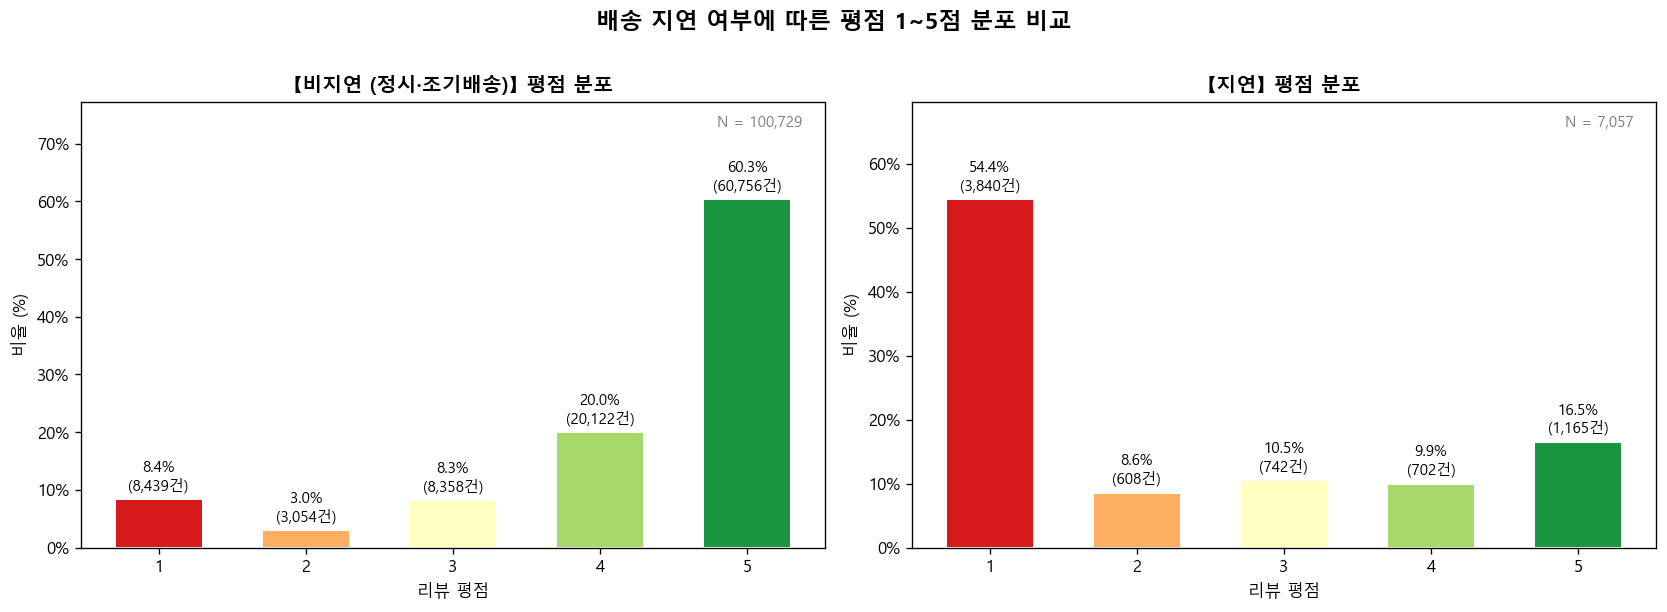

In [62]:
# 지연 여부 × 평점 집계
score_dist = (
    df.groupby(['is_late', 'score_int'])['order_id']
    .count().reset_index(name='cnt')
)
total_by_group = score_dist.groupby('is_late')['cnt'].transform('sum')
score_dist['pct'] = score_dist['cnt'] / total_by_group * 100
score_dist['label'] = score_dist['is_late'].map({False: '비지연 (정시·조기배송)', True: '지연'})

palette = {1: '#d7191c', 2: '#fdae61', 3: '#ffffbf', 4: '#a6d96a', 5: '#1a9641'}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, (late_val, grp_lbl) in zip(axes, {False: '비지연 (정시·조기배송)', True: '지연'}.items()):
    sub = score_dist[score_dist['is_late'] == late_val].sort_values('score_int')
    bars = ax.bar(sub['score_int'].astype(str), sub['pct'],
                  color=[palette[s] for s in sub['score_int']],
                  edgecolor='white', linewidth=1.2, width=0.6)
    for bar, pct, cnt in zip(bars, sub['pct'], sub['cnt']):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.8,
                f'{pct:.1f}%\n({cnt:,}건)', ha='center', va='bottom', fontsize=9)
    ax.set_title(f'【{grp_lbl}】 평점 분포', fontsize=12, fontweight='bold')
    ax.set_xlabel('리뷰 평점', fontsize=10)
    ax.set_ylabel('비율 (%)', fontsize=10)
    ax.set_ylim(0, sub['pct'].max() * 1.28)
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))
    ax.text(0.97, 0.97, f'N = {sub["cnt"].sum():,}',
            transform=ax.transAxes, ha='right', va='top', fontsize=9, color='gray')

fig.suptitle('배송 지연 여부에 따른 평점 1~5점 분포 비교',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

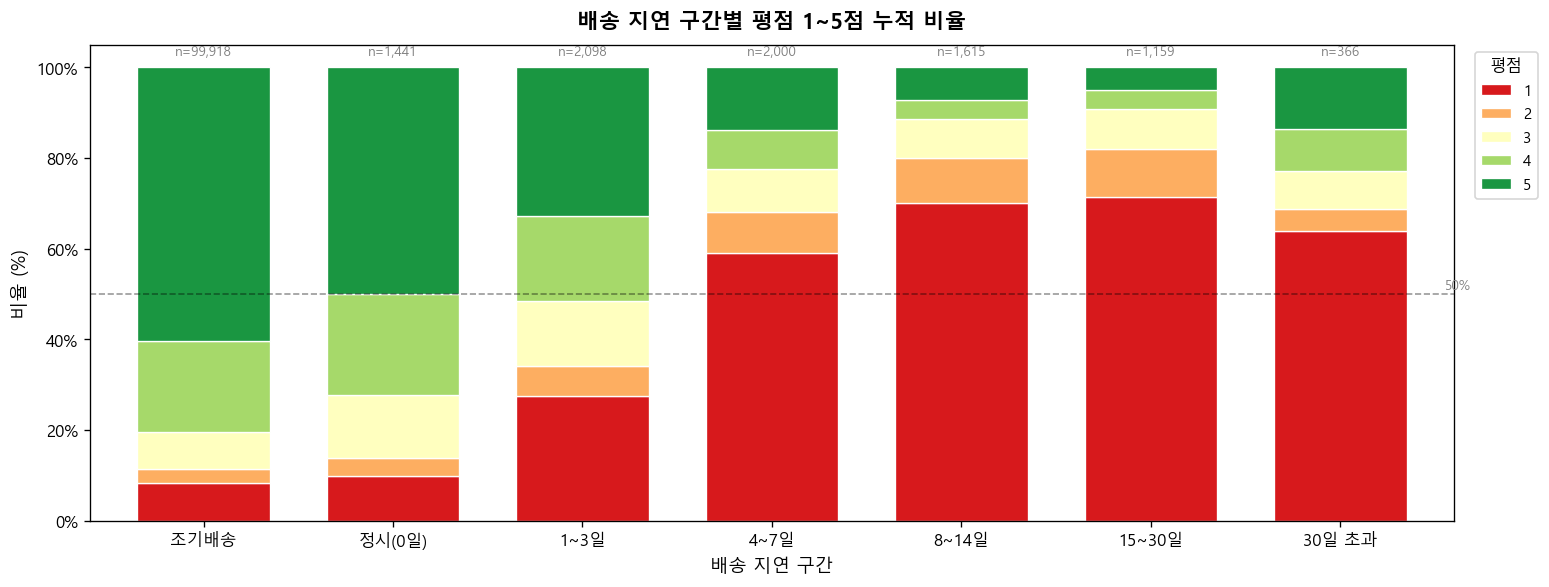

In [63]:
# 지연 구간(7단계) × 평점 누적 막대
bucket_dist = (
    df.groupby(['delay_bucket', 'score_int'])['order_id']
    .count().reset_index(name='cnt')
)
bucket_total = bucket_dist.groupby('delay_bucket')['cnt'].transform('sum')
bucket_dist['pct'] = bucket_dist['cnt'] / bucket_total * 100

pivot_pct = (
    bucket_dist
    .pivot_table(index='delay_bucket', columns='score_int', values='pct', fill_value=0)
    .reindex(labels)
)

fig, ax = plt.subplots(figsize=(13, 5))
pivot_pct.plot(kind='bar', stacked=True, ax=ax,
               color=[palette[s] for s in pivot_pct.columns],
               edgecolor='white', linewidth=0.8, width=0.7)
ax.set_title('배송 지연 구간별 평점 1~5점 누적 비율', fontsize=13, fontweight='bold', pad=10)
ax.set_xlabel('배송 지연 구간', fontsize=11)
ax.set_ylabel('비율 (%)', fontsize=11)
ax.set_xticklabels(labels, rotation=0, fontsize=10)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))
ax.legend(title='평점', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
ax.axhline(50, color='black', lw=1.0, ls='--', alpha=0.4)
ax.text(6.55, 51, '50%', fontsize=8, color='gray')

bucket_n = df.groupby('delay_bucket')['order_id'].count().reindex(labels)
for i, n in enumerate(bucket_n):
    ax.text(i, 102, f'n={int(n):,}', ha='center', va='bottom', fontsize=8, color='gray')

plt.tight_layout()
plt.show()

---
## 3. 판매자 귀책 지연(물류사 인도 병목) × 평점 변화

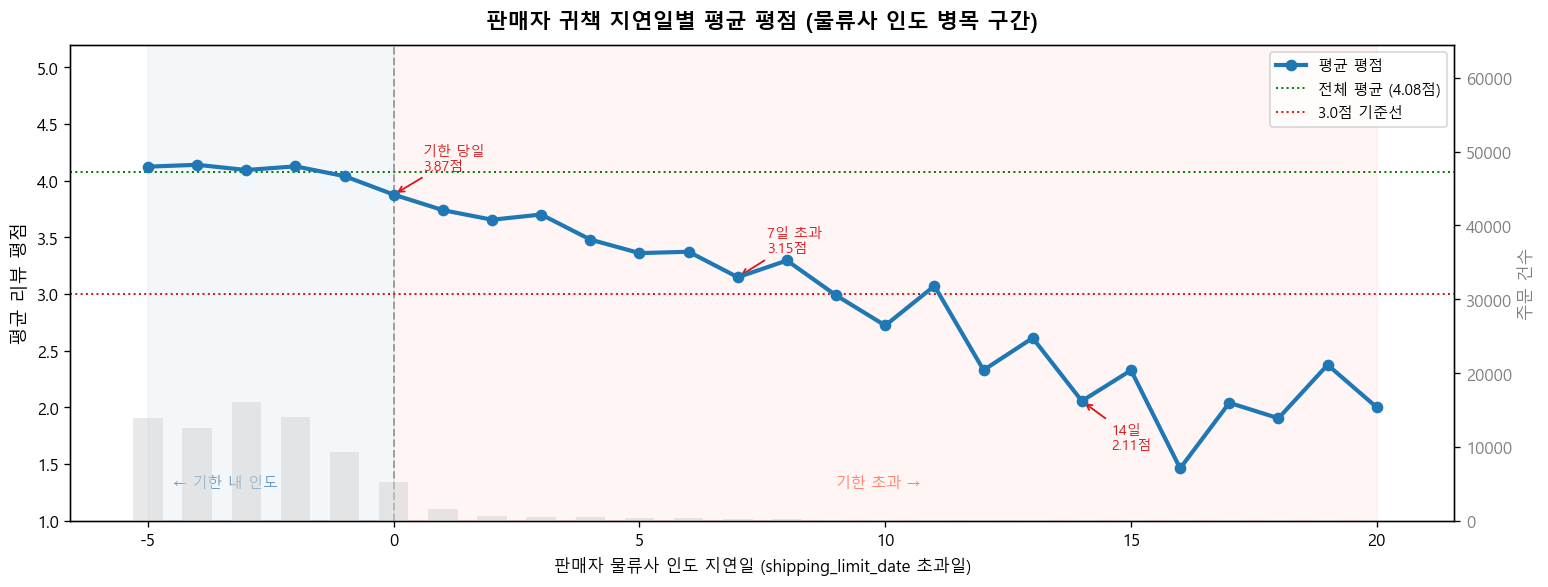

In [64]:
# 판매자 지연일별 평균 평점
seller_score = (
    df.groupby('seller_delay_days')['review_score_mean']
    .agg(mean_score='mean', order_cnt='count')
    .loc[-5:20].reset_index()
)

fig, ax1 = plt.subplots(figsize=(13, 5))
ax2 = ax1.twinx()

ax1.axvspan(-5,  0, alpha=0.06, color='steelblue')
ax1.axvspan( 0, 20, alpha=0.06, color='tomato')
ax1.axvline(x=0, color='gray', lw=1.2, ls='--', alpha=0.7)

ax2.bar(seller_score['seller_delay_days'], seller_score['order_cnt'],
        color='lightgray', alpha=0.5, width=0.6)
ax2.set_ylabel('주문 건수', color='gray', fontsize=10)
ax2.tick_params(axis='y', labelcolor='gray')
ax2.set_ylim(0, seller_score['order_cnt'].max() * 4)

ax1.plot(seller_score['seller_delay_days'], seller_score['mean_score'],
         color='#1f78b4', lw=2.5, marker='o', ms=6, zorder=5, label='평균 평점')

overall_mean = df['review_score_mean'].mean()
ax1.axhline(overall_mean, color='green', lw=1.2, ls=':',
            label=f'전체 평균 ({overall_mean:.2f}점)')
ax1.axhline(3.0, color='#d7191c', lw=1.2, ls=':', label='3.0점 기준선')

for xval, txt, yoff in [(0, '기한 당일\n3.87점', 0.22),
                         (7, '7일 초과\n3.15점', 0.22),
                         (14,'14일\n2.11점',    -0.42)]:
    row = seller_score[seller_score['seller_delay_days'] == xval]
    if not row.empty:
        y = row['mean_score'].values[0]
        ax1.annotate(txt, xy=(xval, y), xytext=(xval + 0.6, y + yoff),
                     fontsize=8.5, color='#d7191c',
                     arrowprops=dict(arrowstyle='->', color='#d7191c', lw=1.1))

ax1.set_xlabel('판매자 물류사 인도 지연일 (shipping_limit_date 초과일)', fontsize=10)
ax1.set_ylabel('평균 리뷰 평점', fontsize=11)
ax1.set_ylim(1, 5.2)
ax1.set_title('판매자 귀책 지연일별 평균 평점 (물류사 인도 병목 구간)', fontsize=13,
              fontweight='bold', pad=10)
ax1.legend(loc='upper right', fontsize=9)
ax1.text(-4.5, 1.3, '← 기한 내 인도', color='steelblue', fontsize=9, alpha=0.8)
ax1.text(9,   1.3,  '기한 초과 →',    color='tomato',   fontsize=9, alpha=0.8)
plt.tight_layout()
plt.show()

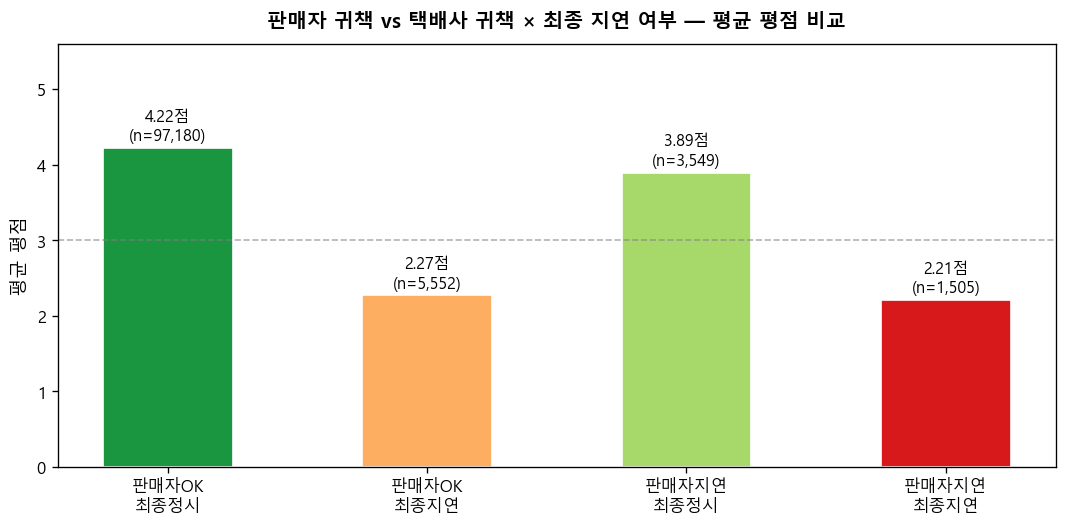

▶ 조합별 평균 평점
         그룹  mean_score   cnt
판매자OK\n최종정시    4.220083 97180
판매자OK\n최종지연    2.268282  5552
판매자지연\n최종정시    3.891519  3549
판매자지연\n최종지연    2.207973  1505


In [65]:
# 판매자 귀책 × 최종 지연 조합 2×2 비교
combo = (
    df.groupby(['is_seller_late', 'is_late'])['review_score_mean']
    .agg(mean_score='mean', cnt='count').reset_index()
)
combo['그룹'] = combo.apply(
    lambda r: (
        '판매자OK\n최종정시'   if (not r['is_seller_late'] and not r['is_late']) else
        '판매자OK\n최종지연'   if (not r['is_seller_late'] and     r['is_late']) else
        '판매자지연\n최종정시' if (    r['is_seller_late'] and not r['is_late']) else
        '판매자지연\n최종지연'
    ), axis=1
)

fig, ax = plt.subplots(figsize=(9, 4.5))
colors = ['#1a9641', '#fdae61', '#a6d96a', '#d7191c']
bars = ax.bar(combo['그룹'], combo['mean_score'],
              color=colors, edgecolor='white', linewidth=1, width=0.5)
for bar, row in zip(bars, combo.itertuples()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
            f'{row.mean_score:.2f}점\n(n={row.cnt:,})',
            ha='center', va='bottom', fontsize=9.5)

ax.axhline(3.0, color='gray', lw=1, ls='--', alpha=0.6)
ax.set_ylim(0, 5.6)
ax.set_ylabel('평균 평점', fontsize=11)
ax.set_title('판매자 귀책 vs 택배사 귀책 × 최종 지연 여부 — 평균 평점 비교',
             fontsize=12, fontweight='bold', pad=10)
ax.tick_params(axis='x', labelsize=10)
plt.tight_layout()
plt.show()

print('▶ 조합별 평균 평점')
print(combo[['그룹', 'mean_score', 'cnt']].to_string(index=False))

---
## 4. 고객 인내 임계일 분석 — 사전 개입 기점 도출

C:\Users\sun94\AppData\Local\Temp\ipykernel_7492\2982695721.py:67: UserWarning: Glyph 9888 (\N{WARNING SIGN}) missing from font(s) Malgun Gothic.
  plt.tight_layout()
c:\team-oldest-olist-analysis\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9888 (\N{WARNING SIGN}) missing from font(s) Malgun Gothic.
  fig.canvas.print_figure(bytes_io, **kw)


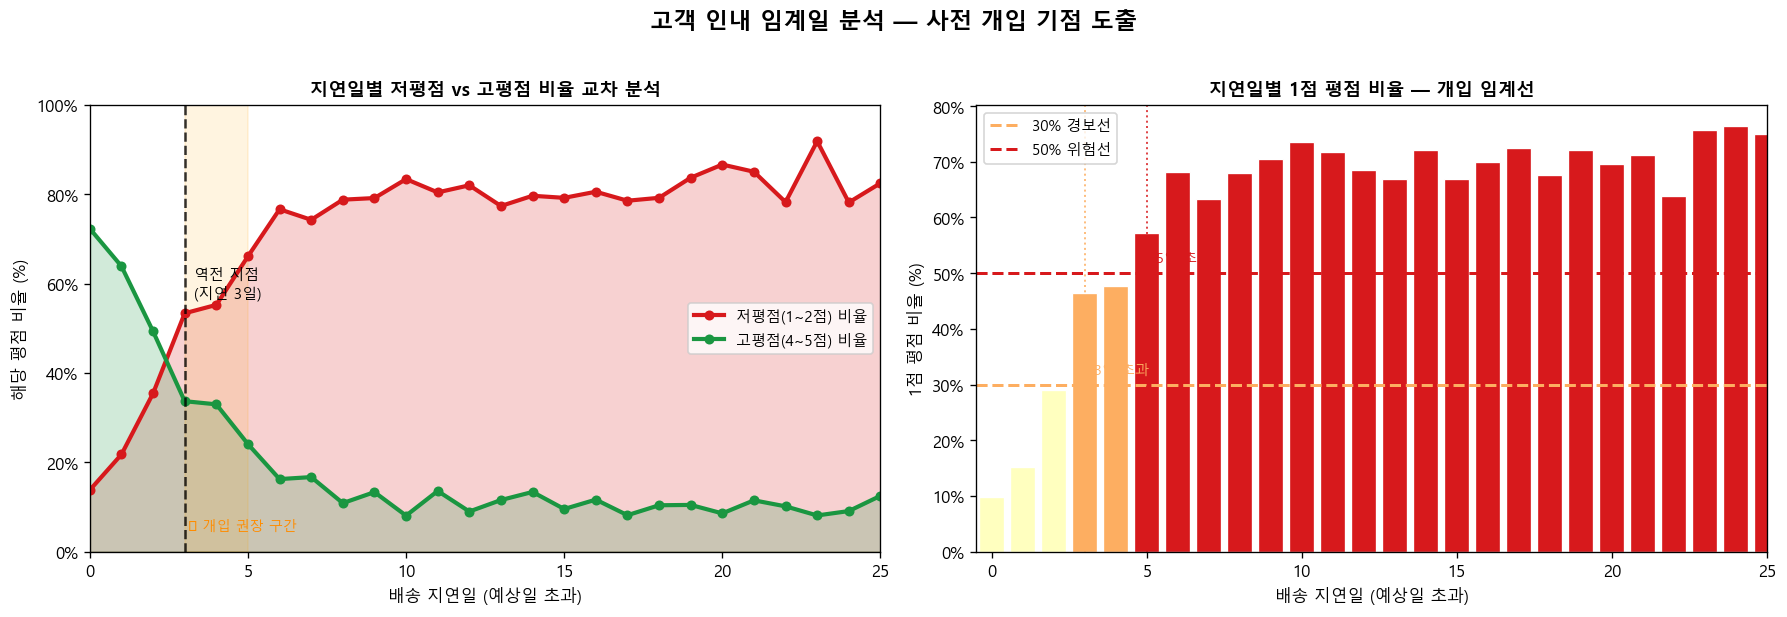

In [66]:
# 지연일별 저/고평점 비율 교차 분석
daily = (
    df[df['delay_days'].between(0, 25)]
    .groupby('delay_days')
    .agg(
        total     =('review_score_mean', 'count'),
        score1    =('score_int', lambda x: (x == 1).sum()),
        score12   =('score_int', lambda x: x.isin([1, 2]).sum()),
        score45   =('score_int', lambda x: x.isin([4, 5]).sum()),
    ).reset_index()
)
daily['bad_rate']    = daily['score12'] / daily['total'] * 100
daily['good_rate']   = daily['score45'] / daily['total'] * 100
daily['score1_rate'] = daily['score1']  / daily['total'] * 100

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# ── 왼쪽: 저평점 vs 고평점 비율 교차
ax = axes[0]
ax.fill_between(daily['delay_days'], daily['bad_rate'],  alpha=0.2, color='#d7191c')
ax.fill_between(daily['delay_days'], daily['good_rate'], alpha=0.2, color='#1a9641')
ax.plot(daily['delay_days'], daily['bad_rate'],  color='#d7191c', lw=2.5,
        marker='o', ms=5, label='저평점(1~2점) 비율')
ax.plot(daily['delay_days'], daily['good_rate'], color='#1a9641', lw=2.5,
        marker='o', ms=5, label='고평점(4~5점) 비율')

cross = daily[daily['bad_rate'] >= daily['good_rate']]
if not cross.empty:
    cx = cross.iloc[0]['delay_days']
    ax.axvline(cx, color='black', lw=1.5, ls='--', alpha=0.8)
    ax.text(cx + 0.3, 57, f'역전 지점\n(지연 {int(cx)}일)', fontsize=9)

ax.axvspan(3, 5, alpha=0.12, color='orange')
ax.text(3.1, 5, '⚠ 개입 권장 구간', fontsize=8.5, color='darkorange')
ax.set_xlabel('배송 지연일 (예상일 초과)', fontsize=10)
ax.set_ylabel('해당 평점 비율 (%)', fontsize=10)
ax.set_title('지연일별 저평점 vs 고평점 비율 교차 분석', fontsize=11, fontweight='bold')
ax.legend(fontsize=9)
ax.set_xlim(0, 25)
ax.set_ylim(0, 100)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))

# ── 오른쪽: 1점 비율 단독 + 임계선
ax = axes[1]
bar_colors = ['#d7191c' if r >= 50 else '#fdae61' if r >= 30 else '#ffffbf'
              for r in daily['score1_rate']]
ax.bar(daily['delay_days'], daily['score1_rate'],
       color=bar_colors, edgecolor='white', linewidth=0.8)

for threshold, col, lbl in [(30, '#fdae61', '30% 경보선'), (50, '#d7191c', '50% 위험선')]:
    ax.axhline(threshold, color=col, lw=1.8, ls='--', label=lbl)
    exceed = daily[daily['score1_rate'] >= threshold]
    if not exceed.empty:
        ex_day = exceed.iloc[0]['delay_days']
        ax.axvline(ex_day, color=col, lw=1.2, ls=':', alpha=0.8)
        ax.text(ex_day + 0.3, threshold + 2, f'{int(ex_day)}일 초과', fontsize=8.5, color=col)

ax.set_xlabel('배송 지연일 (예상일 초과)', fontsize=10)
ax.set_ylabel('1점 평점 비율 (%)', fontsize=10)
ax.set_title('지연일별 1점 평점 비율 — 개입 임계선', fontsize=11, fontweight='bold')
ax.legend(fontsize=9)
ax.set_xlim(-0.5, 25)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))

fig.suptitle('고객 인내 임계일 분석 — 사전 개입 기점 도출',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

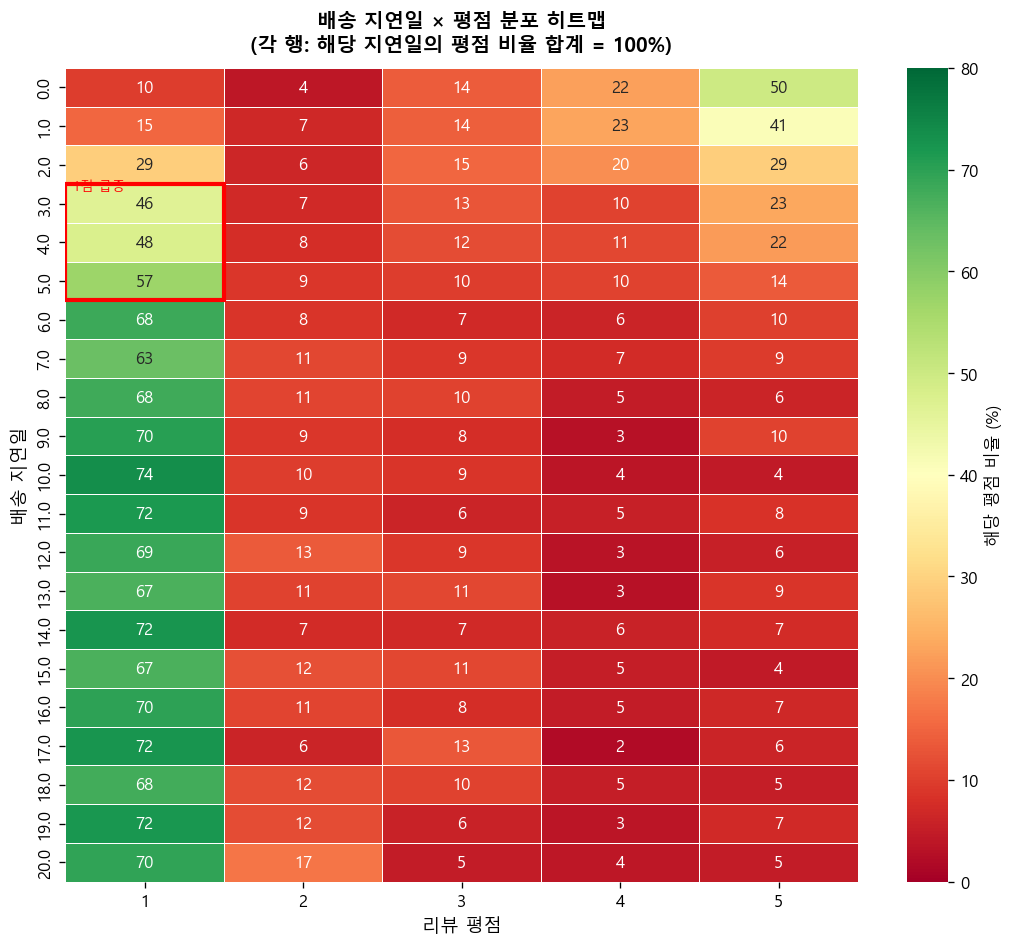

▶ 지연일 0~10일 — 1점 평점 비율 추이
delay_days
0.0      9.8%
1.0     15.2%
2.0     29.1%
3.0     46.5%
4.0     47.7%
5.0     57.1%
6.0     68.2%
7.0     63.2%
8.0     67.9%
9.0     70.4%
10.0    73.5%


In [67]:
# 히트맵: 지연일 × 평점 밀도 (행 단위 비율)
from matplotlib.patches import Rectangle

heat_data = (
    df[df['delay_days'].between(0, 20)]
    .groupby(['delay_days', 'score_int'])['order_id']
    .count().unstack(fill_value=0)
)
heat_pct = heat_data.div(heat_data.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(9, 8))
sns.heatmap(heat_pct, annot=True, fmt='.0f', cmap='RdYlGn',
            vmin=0, vmax=80, linewidths=0.4, ax=ax,
            cbar_kws={'label': '해당 평점 비율 (%)'})
ax.set_xlabel('리뷰 평점', fontsize=11)
ax.set_ylabel('배송 지연일', fontsize=11)
ax.set_title('배송 지연일 × 평점 분포 히트맵\n(각 행: 해당 지연일의 평점 비율 합계 = 100%)',
             fontsize=12, fontweight='bold', pad=10)

# 1점 급증 구간 강조 박스 (지연 3~5일)
score1_col_idx = list(heat_pct.columns).index(1) if 1 in heat_pct.columns else 0
ax.add_patch(Rectangle((score1_col_idx, 3), 1, 3, fill=False,
                        edgecolor='red', lw=2.5, zorder=5))
ax.text(score1_col_idx + 0.05, 3.15, '1점 급증', fontsize=8, color='red')

plt.tight_layout()
plt.show()

print('▶ 지연일 0~10일 — 1점 평점 비율 추이')
if 1 in heat_pct.columns:
    print(heat_pct[1].iloc[:11].apply(lambda x: f'{x:.1f}%').to_string())

---
## 5. 판매자 귀책 지연 비율 분석

전체 지연 중 **판매자가 shipping_limit_date를 초과**한 비율과  
그 분포를 지역·카테고리·시계열 관점에서 시각화한다.

C:\Users\sun94\AppData\Local\Temp\ipykernel_7492\1691143809.py:57: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(group_stats['delay_group'], rotation=10, ha='right', fontsize=9.5)


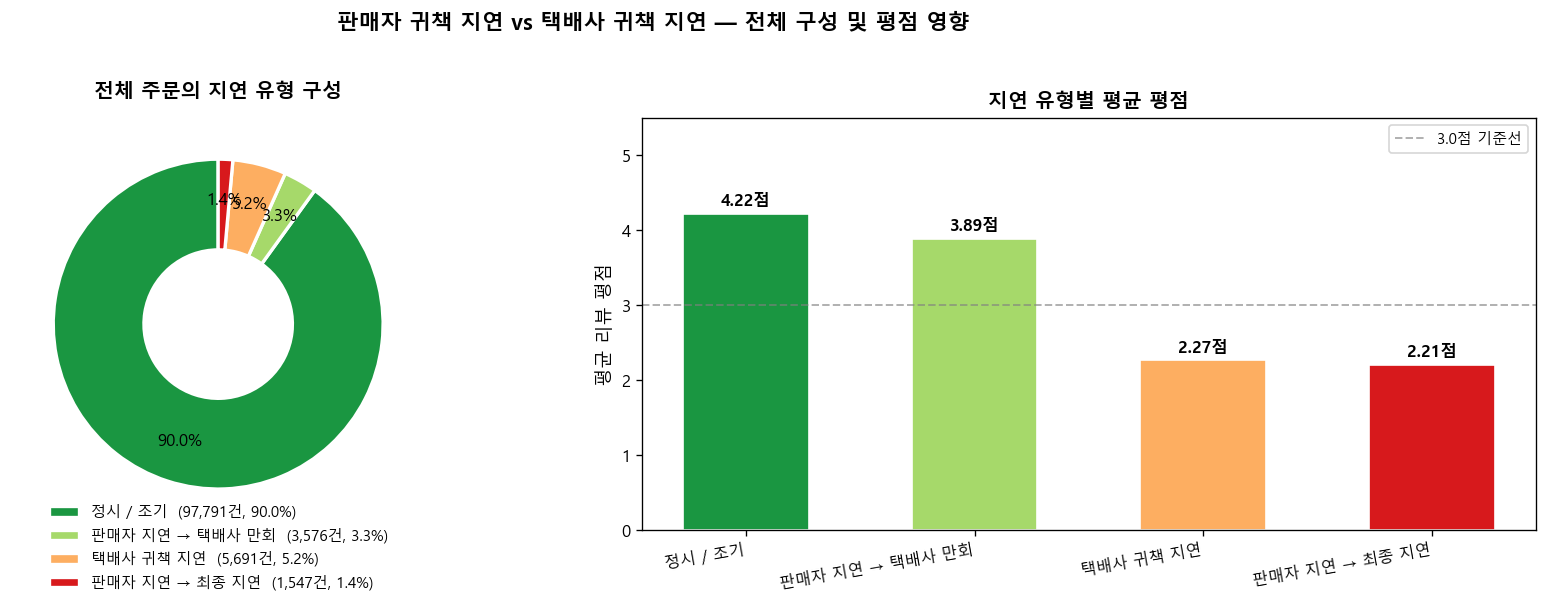

▶ 지연 유형별 요약
    delay_group   cnt       pct  avg_score
        정시 / 조기 97791 90.042816   4.220083
판매자 지연 → 택배사 만회  3576  3.292666   3.891519
      택배사 귀책 지연  5691  5.240090   2.268282
 판매자 지연 → 최종 지연  1547  1.424428   2.207973

▶ 지연 주문(7,238건) 중 판매자 귀책 비율: 21.4%


In [68]:
# ── 5-1. 전체 주문을 4가지 지연 유형으로 분류 ──────────────────────────────

df['delay_group'] = '정시 / 조기'
df.loc[ df['is_late'] &  df['is_seller_late'], 'delay_group'] = '판매자 지연 → 최종 지연'
df.loc[ df['is_late'] & ~df['is_seller_late'], 'delay_group'] = '택배사 귀책 지연'
df.loc[~df['is_late'] &  df['is_seller_late'], 'delay_group'] = '판매자 지연 → 택배사 만회'

group_stats = (
    df.groupby('delay_group')
    .agg(cnt=('order_id','count'), avg_score=('review_score_mean','mean'))
    .reset_index()
)
group_stats['pct'] = group_stats['cnt'] / len(df) * 100

ORDER = ['정시 / 조기', '판매자 지연 → 택배사 만회', '택배사 귀책 지연', '판매자 지연 → 최종 지연']
group_stats = group_stats.set_index('delay_group').reindex(ORDER).reset_index()

COLORS = ['#1a9641', '#a6d96a', '#fdae61', '#d7191c']

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# ── 왼쪽: 도넛 차트 (구성 비율)
ax = axes[0]
wedges, texts, autotexts = ax.pie(
    group_stats['pct'],
    labels=None,
    colors=COLORS,
    autopct='%1.1f%%',
    startangle=90,
    pctdistance=0.75,
    wedgeprops=dict(width=0.55, edgecolor='white', linewidth=2)
)
for at in autotexts:
    at.set_fontsize(10)

# 건수 포함 범례
legend_labels = [
    f'{row["delay_group"]}  ({int(row["cnt"]):,}건, {row["pct"]:.1f}%)'
    for _, row in group_stats.iterrows()
]
ax.legend(wedges, legend_labels, loc='lower center', bbox_to_anchor=(0.5, -0.18),
          fontsize=9, frameon=False)
ax.set_title('전체 주문의 지연 유형 구성', fontsize=12, fontweight='bold', pad=12)

# ── 오른쪽: 유형별 평균 평점 막대
ax = axes[1]
bars = ax.bar(group_stats['delay_group'], group_stats['avg_score'],
              color=COLORS, edgecolor='white', linewidth=1, width=0.55)
for bar, row in zip(bars, group_stats.itertuples()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
            f'{row.avg_score:.2f}점', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.axhline(3.0, color='gray', lw=1.2, ls='--', alpha=0.6, label='3.0점 기준선')
ax.set_ylim(0, 5.5)
ax.set_ylabel('평균 리뷰 평점', fontsize=11)
ax.set_title('지연 유형별 평균 평점', fontsize=12, fontweight='bold')
ax.set_xticklabels(group_stats['delay_group'], rotation=10, ha='right', fontsize=9.5)
ax.legend(fontsize=9)

fig.suptitle('판매자 귀책 지연 vs 택배사 귀책 지연 — 전체 구성 및 평점 영향',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print('▶ 지연 유형별 요약')
print(group_stats[['delay_group','cnt','pct','avg_score']].to_string(index=False))
print(f'\n▶ 지연 주문({df["is_late"].sum():,}건) 중 판매자 귀책 비율: '
      f'{df[df["is_late"] & df["is_seller_late"]].shape[0] / df["is_late"].sum() * 100:.1f}%')

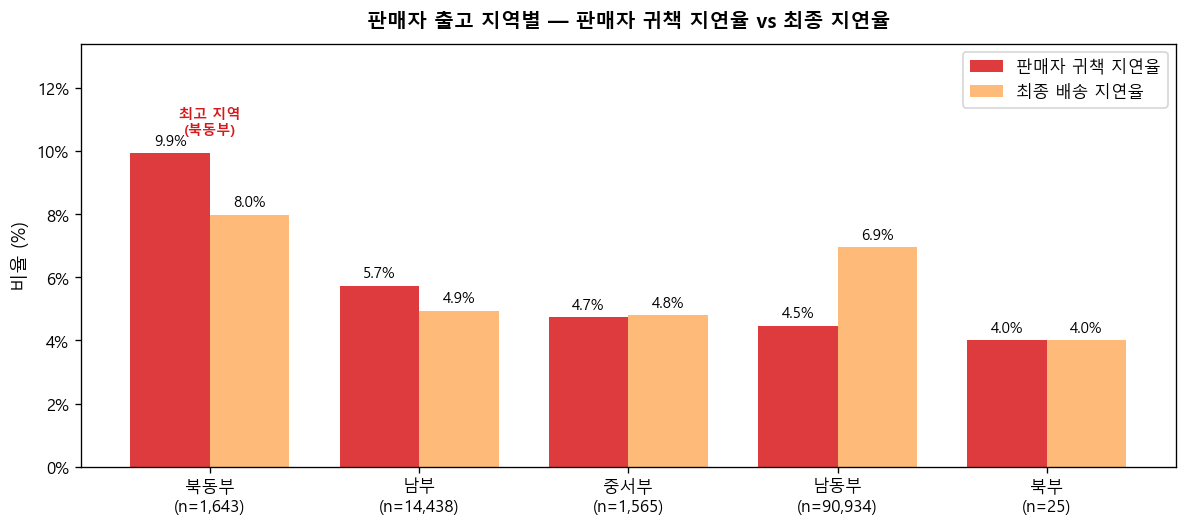

In [69]:
# ── 5-2. 지역별 판매자 귀책 비율 vs 최종 지연율 비교 ─────────────────────────

reg_stats = (
    df.groupby('seller_region')
    .agg(
        total       =('order_id',       'count'),
        seller_late =('is_seller_late', 'sum'),
        final_late  =('is_late',        'sum'),
    )
    .reset_index()
)
reg_stats['seller_late_rate'] = reg_stats['seller_late'] / reg_stats['total'] * 100
reg_stats['final_late_rate']  = reg_stats['final_late']  / reg_stats['total'] * 100
reg_stats = reg_stats.sort_values('seller_late_rate', ascending=False)

fig, ax = plt.subplots(figsize=(10, 4.5))
x = np.arange(len(reg_stats))
w = 0.38

b1 = ax.bar(x - w/2, reg_stats['seller_late_rate'], width=w,
            label='판매자 귀책 지연율', color='#d7191c', alpha=0.85)
b2 = ax.bar(x + w/2, reg_stats['final_late_rate'],  width=w,
            label='최종 배송 지연율',   color='#fdae61', alpha=0.85)

for bar in list(b1) + list(b2):
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + 0.15,
            f'{h:.1f}%', ha='center', va='bottom', fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(
    [f'{r["seller_region"]}\n(n={int(r["total"]):,})' for _, r in reg_stats.iterrows()],
    fontsize=10
)
ax.set_ylabel('비율 (%)', fontsize=11)
ax.set_title('판매자 출고 지역별 — 판매자 귀책 지연율 vs 최종 지연율',
             fontsize=12, fontweight='bold', pad=10)
ax.legend(fontsize=10)
ax.set_ylim(0, reg_stats[['seller_late_rate','final_late_rate']].max().max() * 1.35)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))

# 북동부 강조 주석
top_region = reg_stats.iloc[0]['seller_region']
ax.text(0, reg_stats.iloc[0]['seller_late_rate'] + 0.6,
        f'최고 지역\n({top_region})', ha='center', fontsize=8.5,
        color='#d7191c', fontweight='bold')

plt.tight_layout()
plt.show()

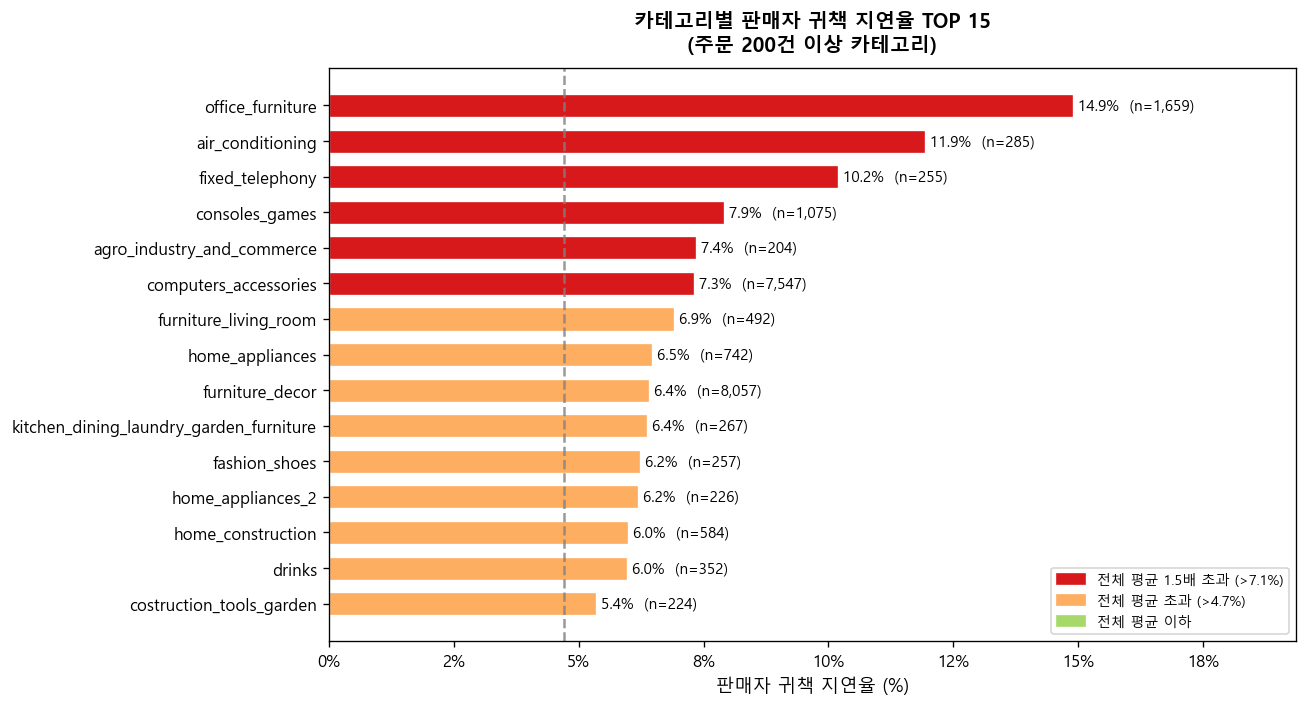

In [70]:
# ── 5-3. 카테고리별 판매자 귀책 비율 (상위 15, 200건 이상) ───────────────────

cat_stats = (
    df.groupby('product_category_name_english')
    .agg(total=('order_id','count'), seller_late=('is_seller_late','sum'))
    .query('total >= 200')
    .reset_index()
)
cat_stats['seller_late_rate'] = cat_stats['seller_late'] / cat_stats['total'] * 100
cat_top15 = cat_stats.sort_values('seller_late_rate', ascending=True).tail(15)

# 전체 평균 기준선
overall_seller_rate = df['is_seller_late'].mean() * 100

fig, ax = plt.subplots(figsize=(11, 6))
bar_colors = ['#d7191c' if r >= overall_seller_rate * 1.5 else
              '#fdae61' if r >= overall_seller_rate else
              '#a6d96a'
              for r in cat_top15['seller_late_rate']]
bars = ax.barh(cat_top15['product_category_name_english'],
               cat_top15['seller_late_rate'],
               color=bar_colors, edgecolor='white', linewidth=0.8, height=0.65)

for bar, row in zip(bars, cat_top15.itertuples()):
    ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
            f'{row.seller_late_rate:.1f}%  (n={int(row.total):,})',
            va='center', fontsize=9)

ax.axvline(overall_seller_rate, color='gray', lw=1.5, ls='--', alpha=0.8,
           label=f'전체 평균 ({overall_seller_rate:.1f}%)')
ax.set_xlabel('판매자 귀책 지연율 (%)', fontsize=11)
ax.set_title('카테고리별 판매자 귀책 지연율 TOP 15\n(주문 200건 이상 카테고리)',
             fontsize=12, fontweight='bold', pad=10)
ax.legend(fontsize=9)
ax.set_xlim(0, cat_top15['seller_late_rate'].max() * 1.3)
ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))

# 색상 범례 설명
from matplotlib.patches import Patch
legend_patches = [
    Patch(color='#d7191c', label=f'전체 평균 1.5배 초과 (>{overall_seller_rate*1.5:.1f}%)'),
    Patch(color='#fdae61', label=f'전체 평균 초과 (>{overall_seller_rate:.1f}%)'),
    Patch(color='#a6d96a', label='전체 평균 이하'),
]
ax.legend(handles=legend_patches, fontsize=8.5, loc='lower right')
plt.tight_layout()
plt.show()

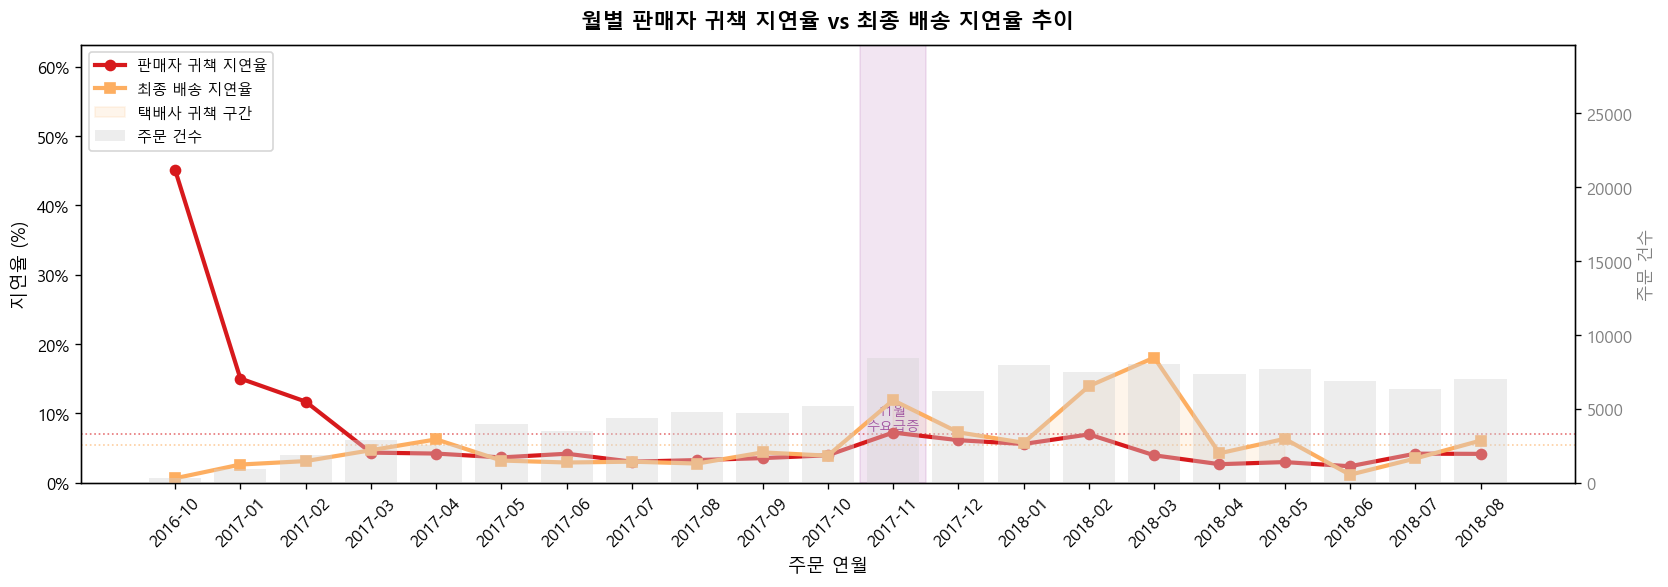

▶ 월별 요약 (100건 이상)
     연월  주문수    판매자귀책%     최종지연%
2016-10  308 45.129870  0.649351
2017-01  911 15.038419  2.634468
2017-02 1853 11.710739  3.130059
2017-03 2895  4.352332  4.697755
2017-04 2538  4.215918  6.264775
2017-05 3987  3.661901  3.210434
2017-06 3483  4.191789  2.928510
2017-07 4366  3.046267  3.046267
2017-08 4788  3.279031  2.777778
2017-09 4721  3.558568  4.384664
2017-10 5214  3.970081  3.912543
2017-11 8474  7.245693 11.907010
2017-12 6181  6.147873  7.280375
2018-01 8005  5.596502  5.771393
2018-02 7504  6.982942 13.939232
2018-03 8015  3.967561 18.053649
2018-04 7380  2.682927  4.254743
2018-05 7728  2.989130  6.340580
2018-06 6872  2.386496  1.164144
2018-07 6331  4.201548  3.506555
2018-08 7047  4.171988  6.087697


In [71]:
# ── 5-4. 월별 판매자 귀책 지연율 vs 최종 지연율 추이 ────────────────────────

df['purchase_yearmonth'] = pd.to_datetime(df['order_purchase_timestamp']).dt.to_period('M')

monthly = (
    df.groupby('purchase_yearmonth')
    .agg(total=('order_id','count'),
         seller_late=('is_seller_late','sum'),
         final_late=('is_late','sum'))
    .reset_index()
)
monthly['seller_late_rate'] = monthly['seller_late'] / monthly['total'] * 100
monthly['final_late_rate']  = monthly['final_late']  / monthly['total'] * 100
monthly['ym_str'] = monthly['purchase_yearmonth'].astype(str)

# 초기 데이터 노이즈 제거 (100건 미만 월 제외)
monthly_clean = monthly[monthly['total'] >= 100].copy()

fig, ax1 = plt.subplots(figsize=(14, 5))
ax2 = ax1.twinx()

# 배경 막대: 주문 건수
ax2.bar(monthly_clean['ym_str'], monthly_clean['total'],
        color='lightgray', alpha=0.4, width=0.8, label='주문 건수')
ax2.set_ylabel('주문 건수', color='gray', fontsize=10)
ax2.tick_params(axis='y', labelcolor='gray')
ax2.set_ylim(0, monthly_clean['total'].max() * 3.5)

# 꺾은선: 두 지연율
ax1.plot(monthly_clean['ym_str'], monthly_clean['seller_late_rate'],
         color='#d7191c', lw=2.5, marker='o', ms=6, zorder=5, label='판매자 귀책 지연율')
ax1.plot(monthly_clean['ym_str'], monthly_clean['final_late_rate'],
         color='#fdae61', lw=2.5, marker='s', ms=6, zorder=5, label='최종 배송 지연율')
ax1.fill_between(monthly_clean['ym_str'],
                 monthly_clean['seller_late_rate'],
                 monthly_clean['final_late_rate'],
                 where=monthly_clean['final_late_rate'] > monthly_clean['seller_late_rate'],
                 alpha=0.12, color='#fdae61', label='택배사 귀책 구간')

# 전체 평균 기준선
avg_s = monthly_clean['seller_late_rate'].mean()
avg_f = monthly_clean['final_late_rate'].mean()
ax1.axhline(avg_s, color='#d7191c', lw=1, ls=':', alpha=0.6)
ax1.axhline(avg_f, color='#fdae61', lw=1, ls=':', alpha=0.6)

# 2017년 11월 급증 구간 강조
nov17_idx = monthly_clean[monthly_clean['ym_str'] == '2017-11'].index
if len(nov17_idx):
    pos = monthly_clean['ym_str'].tolist().index('2017-11')
    ax1.axvspan(pos - 0.5, pos + 0.5, alpha=0.1, color='purple')
    ax1.text(pos, monthly_clean.loc[nov17_idx[0], 'seller_late_rate'] + 0.4,
             '11월\n수요급증', ha='center', fontsize=8, color='purple')

ax1.set_xlabel('주문 연월', fontsize=11)
ax1.set_ylabel('지연율 (%)', fontsize=11)
ax1.set_title('월별 판매자 귀책 지연율 vs 최종 배송 지연율 추이',
              fontsize=13, fontweight='bold', pad=10)
ax1.set_ylim(0, max(monthly_clean['seller_late_rate'].max(),
                    monthly_clean['final_late_rate'].max()) * 1.4)
ax1.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))
ax1.tick_params(axis='x', rotation=45)

lines1, lbs1 = ax1.get_legend_handles_labels()
lines2, lbs2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, lbs1 + lbs2, loc='upper left', fontsize=9)

plt.tight_layout()
plt.show()

print('▶ 월별 요약 (100건 이상)')
print(monthly_clean[['ym_str','total','seller_late_rate','final_late_rate']]
      .rename(columns={'ym_str':'연월','total':'주문수',
                       'seller_late_rate':'판매자귀책%','final_late_rate':'최종지연%'})
      .to_string(index=False))

---
## 6. 간극 분석 — "평균 배송 10일 + 지연 3일 ≠ 20~25일" 원인 규명

### 문제 제기
- 현재 EDA(분석 1): 예상 배송일 기준 **+3일** 시점에 평점 급락
- DY/NG EDA: 실제 배송일 **20~25일** 구간에서 평점 급락
- 평균 실제 배송일 ~10일이라면, **10 + 3 = 13일**이어야 하는데 왜 25일인가?

### 핵심 수식
```
actual_delivery = estimated_window + delay_days
```
두 분석이 같은 현상을 다른 x축으로 보고 있으며, 그 사이에 **estimated_window(예상 배송 윈도우)** 가 숨어 있다.

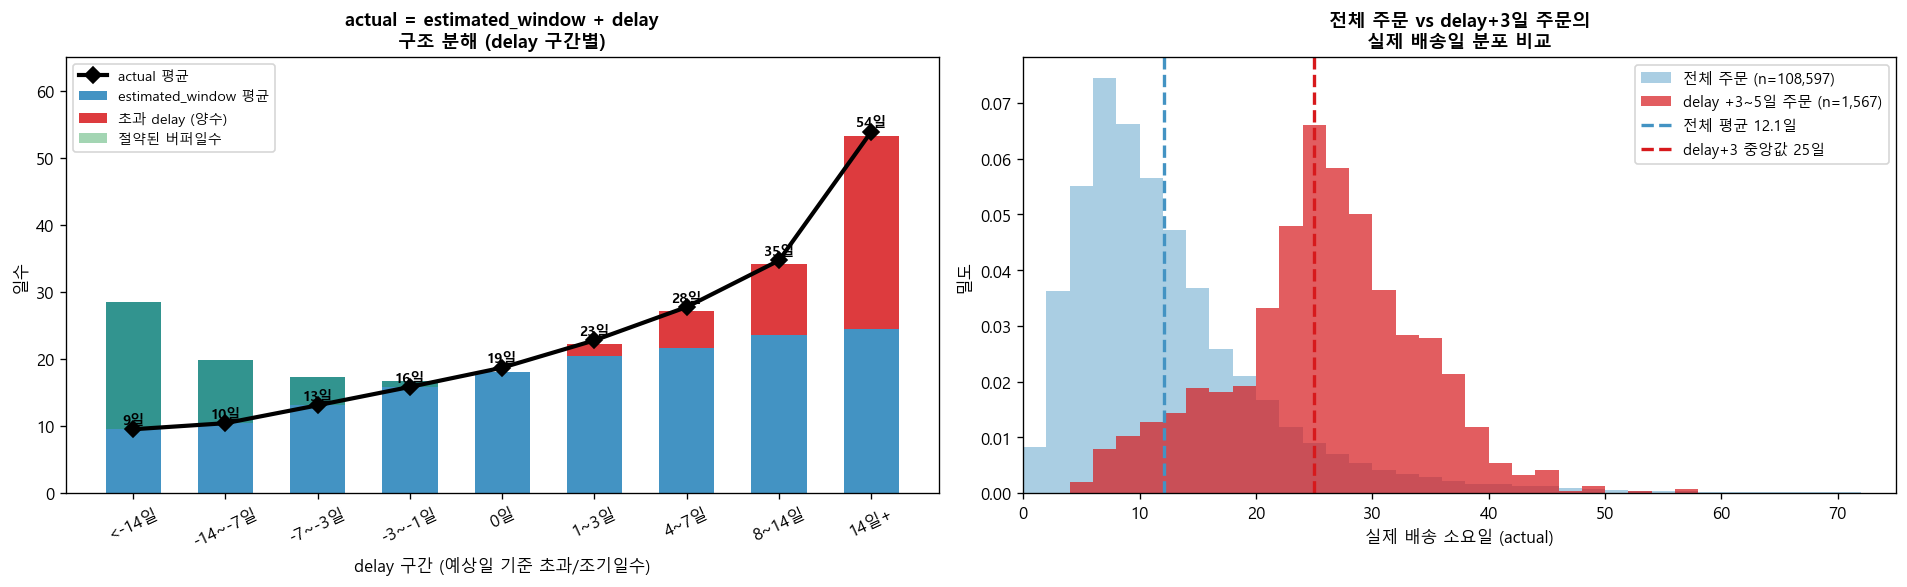

▶ delay 구간별 분해표
delay_seg  estimated_mean  delay_mean  actual_mean   cnt
    <-14일       28.497439  -19.604047     9.494774 47642
  -14~-7일       19.878172  -10.078052    10.399186 38308
   -7~-3일       17.313340   -4.812447    13.070791 10637
   -3~-1일       16.736716   -1.520564    15.810567  3331
       0일       18.069396    0.000000    18.677307  1441
     1~3일       20.352717    1.825548    22.754051  2098
     4~7일       21.611500    5.529000    27.725000  2000
    8~14일       23.528173   10.574613    34.665635  1615
     14일+       24.430820   28.842623    53.855738  1525


In [72]:
# 6-1. actual = estimated + delay 3분해 시각화
# 이 섹션에 필요한 두 컬럼을 여기서 계산
df['actual']    = (df['order_delivered_customer_date']
                   - pd.to_datetime(df['order_purchase_timestamp'])).dt.days
df['estimated'] = (df['order_estimated_delivery_date']
                   - pd.to_datetime(df['order_purchase_timestamp'])).dt.days

# delay 구간별 세 값 평균
bins_d = [-999,-14,-7,-3,-1,0,3,7,14,999]
lbls_d = ['<-14일','-14~-7일','-7~-3일','-3~-1일','0일','1~3일','4~7일','8~14일','14일+']
df['delay_seg'] = pd.cut(df['delay_days'], bins=bins_d, labels=lbls_d)

decomp = (
    df.groupby('delay_seg', observed=True)
    .agg(estimated_mean=('estimated', 'mean'),
         delay_mean    =('delay_days','mean'),
         actual_mean   =('actual',    'mean'),
         cnt           =('actual',    'count'))
    .reset_index()
    .dropna()
)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# ── 왼쪽: actual = estimated(밑) + delay(위) 누적 막대
ax = axes[0]
ax.bar(decomp['delay_seg'], decomp['estimated_mean'],
       color='#4393c3', label='estimated_window 평균', width=0.6)
ax.bar(decomp['delay_seg'], decomp['delay_mean'].clip(lower=0),
       bottom=decomp['estimated_mean'],
       color='#d7191c', alpha=0.85, label='초과 delay (양수)', width=0.6)
# 조기배송 구간: estimated 중 실제로 쓰이지 않은 버퍼
save_days = (decomp['estimated_mean'] - decomp['actual_mean']).clip(lower=0)
ax.bar(decomp['delay_seg'], save_days,
       bottom=decomp['actual_mean'],
       color='#1a9641', alpha=0.4, label='절약된 버퍼일수', width=0.6)

# actual 꺾은선 오버레이
ax.plot(decomp['delay_seg'], decomp['actual_mean'],
        color='black', lw=2.5, marker='D', ms=7, zorder=10, label='actual 평균')
for i, row in decomp.iterrows():
    ax.text(i, row['actual_mean'] + 0.8, f"{row['actual_mean']:.0f}일",
            ha='center', fontsize=8.5, color='black', fontweight='bold')

ax.set_title('actual = estimated_window + delay\n구조 분해 (delay 구간별)',
             fontsize=11, fontweight='bold')
ax.set_xlabel('delay 구간 (예상일 기준 초과/조기일수)', fontsize=10)
ax.set_ylabel('일수', fontsize=10)
ax.tick_params(axis='x', rotation=25)
ax.legend(fontsize=8.5, loc='upper left')
ax.set_ylim(0, 65)

# ── 오른쪽: delay=+3일 주문의 actual 분포 vs 전체 actual 분포 비교
ax = axes[1]
all_actual   = df['actual'].dropna()
late3_actual = df[df['delay_days'].between(3, 5)]['actual'].dropna()

ax.hist(all_actual,   bins=range(0, 80, 2), density=True,
        alpha=0.45, color='#4393c3', label=f'전체 주문 (n={len(all_actual):,})')
ax.hist(late3_actual, bins=range(0, 80, 2), density=True,
        alpha=0.70, color='#d7191c', label=f'delay +3~5일 주문 (n={len(late3_actual):,})')
ax.axvline(all_actual.mean(),    color='#4393c3', lw=2, ls='--',
           label=f'전체 평균 {all_actual.mean():.1f}일')
ax.axvline(late3_actual.median(), color='#d7191c', lw=2, ls='--',
           label=f'delay+3 중앙값 {late3_actual.median():.0f}일')
ax.set_xlabel('실제 배송 소요일 (actual)', fontsize=10)
ax.set_ylabel('밀도', fontsize=10)
ax.set_title('전체 주문 vs delay+3일 주문의\n실제 배송일 분포 비교', fontsize=11, fontweight='bold')
ax.legend(fontsize=9)
ax.set_xlim(0, 75)

plt.tight_layout()
plt.show()

print('▶ delay 구간별 분해표')
print(decomp[['delay_seg','estimated_mean','delay_mean','actual_mean','cnt']].to_string(index=False))

C:\Users\sun94\AppData\Local\Temp\ipykernel_7492\3042107695.py:82: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Malgun Gothic.
  plt.tight_layout()
c:\team-oldest-olist-analysis\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Malgun Gothic.
  fig.canvas.print_figure(bytes_io, **kw)


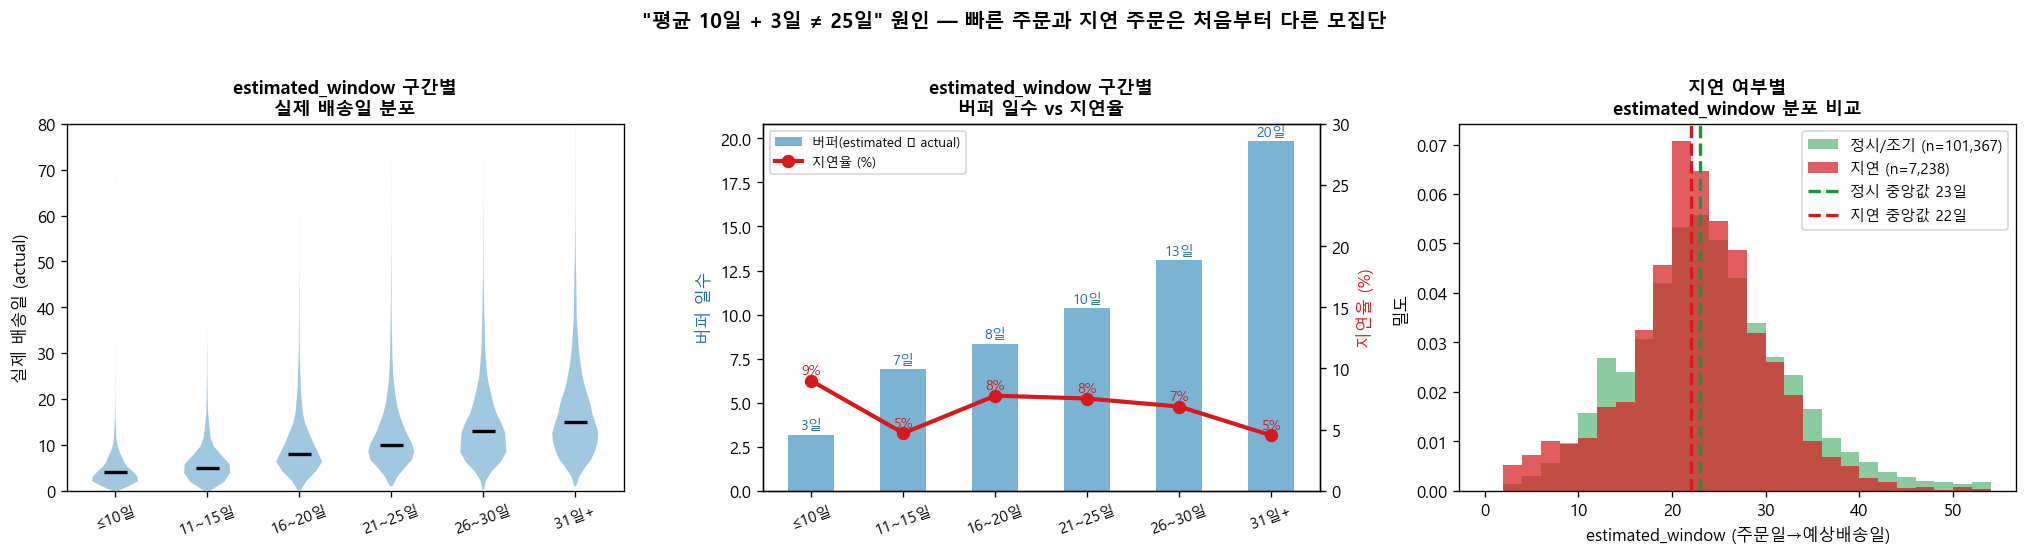

▶ estimated_window 구간별 요약
est_seg  estimated_mean  actual_mean  buffer_days  late_rate   cnt
   ≤10일        7.666263     4.480949     3.185313   0.089886  5774
 11~15일       13.091580     6.193292     6.898288   0.046968 12732
 16~20일       18.287044     9.940981     8.346063   0.077719 21061
 21~25일       22.901112    12.532668    10.368443   0.075371 29677
 26~30일       27.752654    14.684279    13.068375   0.068780 19872
   31일+       36.911247    17.083671    19.827576   0.045172 19481

▶ 정시/조기 그룹  estimated 중앙값: 23일  |  actual 평균: 10.5일
▶ 지연 그룹       estimated 중앙값: 22일  |  actual 평균: 33.3일

▶ delay +3일 주문의 estimated 중앙값: 21일
   → 21(estimated) + 3(delay) = 24일  ← DY/NG의 20~25일 구간과 일치


In [73]:
# 6-2. "빠른 주문"과 "느린 주문"은 처음부터 다른 모집단 — estimated_window 구간 분석

bins_e = [0, 10, 15, 20, 25, 30, 999]
lbls_e = ['≤10일', '11~15일', '16~20일', '21~25일', '26~30일', '31일+']
df['est_seg'] = pd.cut(df['estimated'], bins=bins_e, labels=lbls_e)

est_grp = (
    df.groupby('est_seg', observed=True)
    .agg(actual_mean   =('actual',    'mean'),
         estimated_mean=('estimated', 'mean'),
         late_rate      =('is_late',   'mean'),
         cnt            =('actual',    'count'))
    .reset_index()
    .dropna()
)
est_grp['buffer_days'] = est_grp['estimated_mean'] - est_grp['actual_mean']

fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))

# ── 왼쪽: estimated 구간별 실제 배송일 분포 (violin)
ax = axes[0]
violin_data = [df.loc[df['est_seg'] == seg, 'actual'].dropna().values
               for seg in lbls_e if (df['est_seg'] == seg).any()]
valid_lbls  = [seg for seg in lbls_e if (df['est_seg'] == seg).any()]
vp = ax.violinplot(violin_data, positions=range(len(violin_data)),
                   showmedians=True, showextrema=False)
for pc in vp['bodies']:
    pc.set_facecolor('#4393c3')
    pc.set_alpha(0.5)
vp['cmedians'].set_color('black')
vp['cmedians'].set_linewidth(2)
ax.set_xticks(range(len(valid_lbls)))
ax.set_xticklabels(valid_lbls, rotation=20, fontsize=9)
ax.set_ylabel('실제 배송일 (actual)', fontsize=10)
ax.set_title('estimated_window 구간별\n실제 배송일 분포', fontsize=11, fontweight='bold')
ax.set_ylim(0, 80)

# ── 가운데: 버퍼 일수 + 지연율
ax  = axes[1]
ax2 = ax.twinx()
x   = np.arange(len(est_grp))
ax.bar(x, est_grp['buffer_days'], color='#4393c3', alpha=0.7, width=0.5,
       label='버퍼(estimated − actual)')
ax2.plot(x, est_grp['late_rate'] * 100, color='#d7191c', lw=2.5,
         marker='o', ms=7, label='지연율 (%)')
for xi, row in zip(x, est_grp.itertuples()):
    ax.text(xi, row.buffer_days + 0.3, f'{row.buffer_days:.0f}일',
            ha='center', fontsize=8.5, color='#2166ac')
    ax2.text(xi, row.late_rate * 100 + 0.5, f'{row.late_rate*100:.0f}%',
             ha='center', fontsize=8.5, color='#d7191c')
ax.set_xticks(x)
ax.set_xticklabels(est_grp['est_seg'].astype(str), rotation=20, fontsize=9)
ax.set_ylabel('버퍼 일수', fontsize=10, color='#2166ac')
ax2.set_ylabel('지연율 (%)', fontsize=10, color='#d7191c')
ax2.set_ylim(0, 30)
ax.set_title('estimated_window 구간별\n버퍼 일수 vs 지연율', fontsize=11, fontweight='bold')
lines1, lbs1 = ax.get_legend_handles_labels()
lines2, lbs2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, lbs1 + lbs2, fontsize=8)

# ── 오른쪽: 지연 여부별 estimated_window 분포
ax = axes[2]
ax.hist(df.loc[~df['is_late'], 'estimated'].dropna(),
        bins=range(0, 55, 2), density=True, alpha=0.5,
        color='#1a9641', label=f'정시/조기 (n={(~df["is_late"]).sum():,})')
ax.hist(df.loc[ df['is_late'], 'estimated'].dropna(),
        bins=range(0, 55, 2), density=True, alpha=0.7,
        color='#d7191c', label=f'지연 (n={df["is_late"].sum():,})')
ontime_med = df.loc[~df['is_late'], 'estimated'].median()
late_med   = df.loc[ df['is_late'], 'estimated'].median()
ax.axvline(ontime_med, color='#1a9641', lw=2, ls='--',
           label=f'정시 중앙값 {ontime_med:.0f}일')
ax.axvline(late_med,   color='#d7191c', lw=2, ls='--',
           label=f'지연 중앙값 {late_med:.0f}일')
ax.set_xlabel('estimated_window (주문일→예상배송일)', fontsize=10)
ax.set_ylabel('밀도', fontsize=10)
ax.set_title('지연 여부별\nestimated_window 분포 비교', fontsize=11, fontweight='bold')
ax.legend(fontsize=9)

fig.suptitle('"평균 10일 + 3일 ≠ 25일" 원인 — 빠른 주문과 지연 주문은 처음부터 다른 모집단',
             fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# 핵심 수치 요약
delay3_est_med = df.loc[df['delay_days'].between(3, 5), 'estimated'].median()
print('▶ estimated_window 구간별 요약')
print(est_grp[['est_seg','estimated_mean','actual_mean','buffer_days','late_rate','cnt']].to_string(index=False))
print(f'\n▶ 정시/조기 그룹  estimated 중앙값: {ontime_med:.0f}일  |  actual 평균: {df.loc[~df["is_late"],"actual"].mean():.1f}일')
print(f'▶ 지연 그룹       estimated 중앙값: {late_med:.0f}일  |  actual 평균: {df.loc[ df["is_late"],"actual"].mean():.1f}일')
print(f'\n▶ delay +3일 주문의 estimated 중앙값: {delay3_est_med:.0f}일')
print(f'   → {delay3_est_med:.0f}(estimated) + 3(delay) = {delay3_est_med+3:.0f}일  ← DY/NG의 20~25일 구간과 일치')